In [1]:
# Import all relevant packages for this notebook
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from mplsoccer import Pitch
import socceraction.spadl.config as spadlcfg
import re

# Prior Shift

In [2]:
data_path = Path().resolve().parent / "data" / "vaep_data" / "all_leagues_vaep.h5"
data = pd.HDFStore(str(data_path), mode="r")
full_data = data.vaep_data.copy()

actiontype_map = dict(enumerate(spadlcfg.actiontypes))
full_data["type_name"] = full_data["type_id"].map(actiontype_map).fillna("unknown")

In [3]:
# [print(i) for i in full_data.columns]

In [4]:
def _season_start_year(s):
    m = re.search(r"(\d{4})", str(s))
    return int(m.group(1)) if m else 9999

# selected_league = "La Liga"  # Change this to analyze another league
# league_data = full_data.loc[full_data["competition_name"] == selected_league].copy()

home_col, away_col = "home_score", "away_score"
per_game = full_data.groupby(["season_name", "competition_name", "game_id"])[[home_col, away_col]].max().sum(axis=1).rename("goals")
per_game.head()

season_name  competition_name  game_id
1958         FIFA World Cup    3888704    7
                               3888705    7
1962         FIFA World Cup    3888854    2
1970         FIFA World Cup    3888699    5
                               3888700    1
Name: goals, dtype: int64

In [5]:
min_games = 30
season_goals = per_game.groupby(["season_name", "competition_name"]).agg(["count", "mean", "std"]).fillna(0).reset_index()
season_goals.columns = ["season_name", "competition_name", "num_games", "avg_goals_per_game", "std_goals_per_game"]

season_goals = season_goals[season_goals["num_games"] >= min_games].copy()
season_goals["season_sort"] = season_goals["season_name"].apply(_season_start_year)
season_goals = season_goals.sort_values("season_sort").reset_index(drop=True)

lower, upper=2010,2021
season_goals = season_goals[(season_goals["season_sort"] >= lower) & (season_goals["season_sort"] <= upper)].copy()


In [6]:
focus_leagues = [
    "FA Women's Super League",
    "La Liga",
    "Premier League",
    "Serie A",
    "1. Bundesliga",
    "Ligue 1",
]

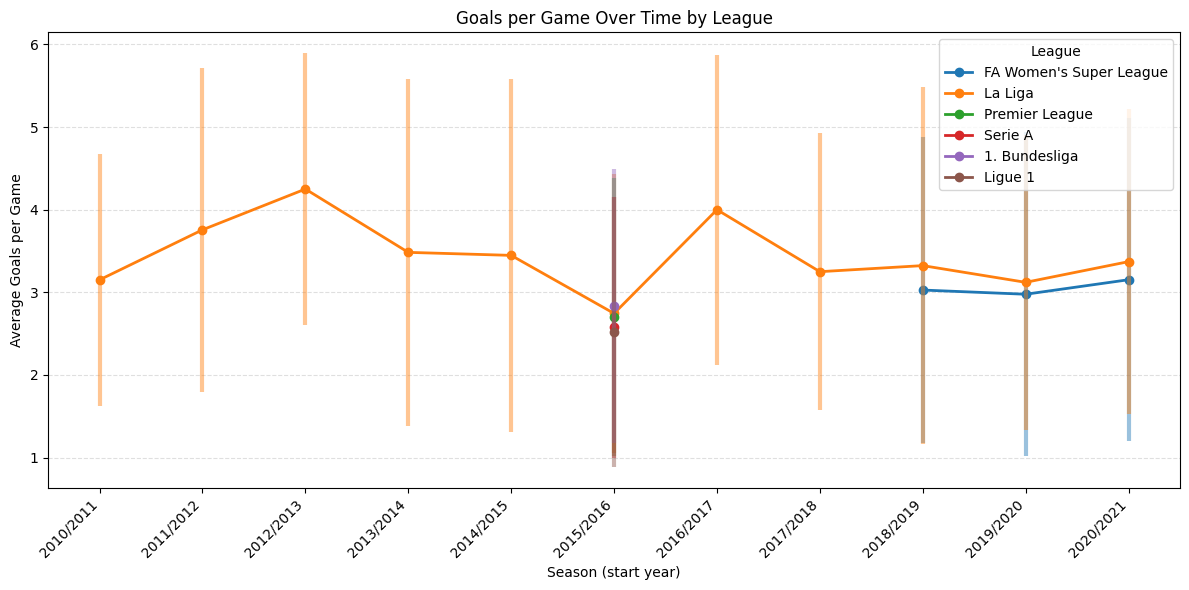

In [7]:
# Filter for focus_leagues and sort by season
plot_df = season_goals[season_goals["competition_name"].isin(focus_leagues)].copy()
plot_df = plot_df.sort_values(["competition_name", "season_sort"])

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors

for i, league in enumerate(focus_leagues):
    league_df = plot_df[plot_df["competition_name"] == league]
    if league_df.empty:
        continue
    # Use season_sort for x, season_name for labels
    ax.plot(
        league_df["season_sort"],
        league_df["avg_goals_per_game"],
        label=league,
        color=colors[i % len(colors)],
        marker="o",
        linewidth=2,
    )
    # Plot standard deviation as a vertical line segment (not a filled bar)
    ax.vlines(
        league_df["season_sort"],
        league_df["avg_goals_per_game"] - league_df["std_goals_per_game"],
        league_df["avg_goals_per_game"] + league_df["std_goals_per_game"],
        color=colors[i % len(colors)],
        alpha=0.45,
        linewidth=3,
    )

# Set x-ticks to season_sort and labels to season_name (unique and sorted)
unique_seasons = plot_df.drop_duplicates("season_sort").sort_values("season_sort")
ax.set_xticks(unique_seasons["season_sort"])
ax.set_xticklabels(unique_seasons["season_name"], rotation=45, ha="right")

ax.set_xlabel("Season (start year)")
ax.set_ylabel("Average Goals per Game")
ax.set_title("Goals per Game Over Time by League")
ax.legend(title="League")
ax.grid(axis="y", linestyle="--", alpha=0.4)
# Add a note about the gap between 2020/2021 and 2022/2023 if present
# This is likely due to missing or filtered-out data for the 2021/2022 season in some leagues.
# Check which seasons are present for each league if you want to investigate further.
plt.tight_layout()
plt.show()

In [8]:
season_year = "2015/2016"
top5_ordered = ["Serie A", "Premier League", "La Liga", "1. Bundesliga", "Ligue 1"]

season_data_top5 = full_data.loc[(full_data["season_name"] == season_year) & (full_data["competition_name"].isin(top5_ordered))].copy()

per_game_top5 = season_data_top5.groupby(["competition_name", "game_id"])[["home_score", "away_score"]].max().sum(axis=1).rename("goals_in_game").reset_index()

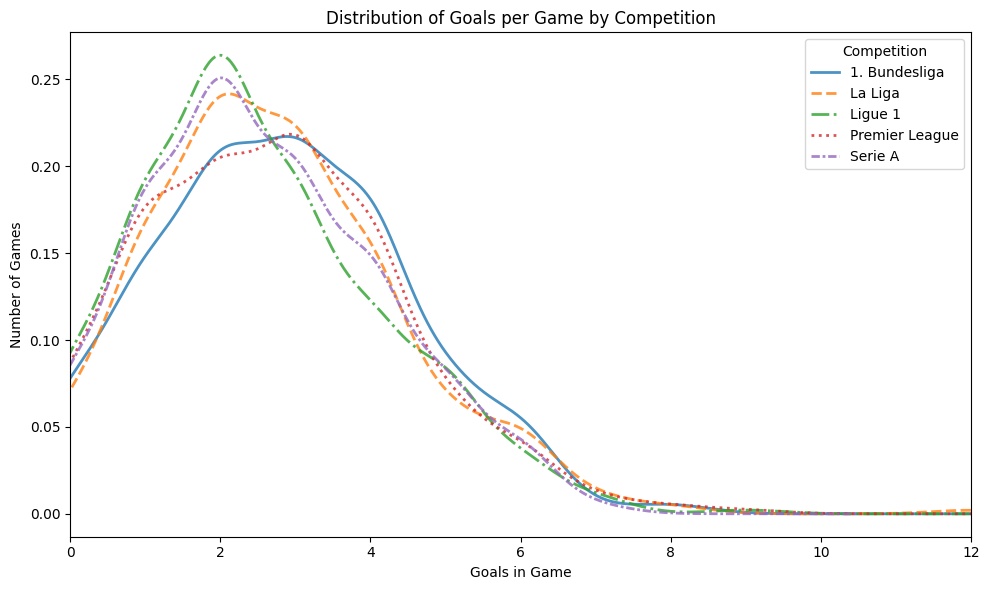

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
linestyles=["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 5))]
for i, league in enumerate(per_game_top5["competition_name"].unique()):
    league_games = per_game_top5[per_game_top5["competition_name"] == league]
    # Plot kernel density estimate instead of histogram
    league_games["goals_in_game"].plot(
        kind="density",
        ax=ax,
        label=league,
        linewidth=2,
        alpha=0.8,
        linestyle=linestyles[i % len(linestyles)]
    )
ax.set_xlim(0,12)
ax.set_xlabel("Goals in Game")
ax.set_ylabel("Number of Games")
ax.set_title("Distribution of Goals per Game by Competition")
ax.legend(title="Competition")
plt.tight_layout()
plt.show()

C:\Users\Antonio\AppData\Local\Temp\ipykernel_18384\1129361669.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby("competition_name")["goals_in_game"]
C:\Users\Antonio\AppData\Local\Temp\ipykernel_18384\1129361669.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby("competition_name")["goals_in_game"]
C:\Users\Antonio\AppData\Local\Temp\ipykernel_18384\1129361669.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future de

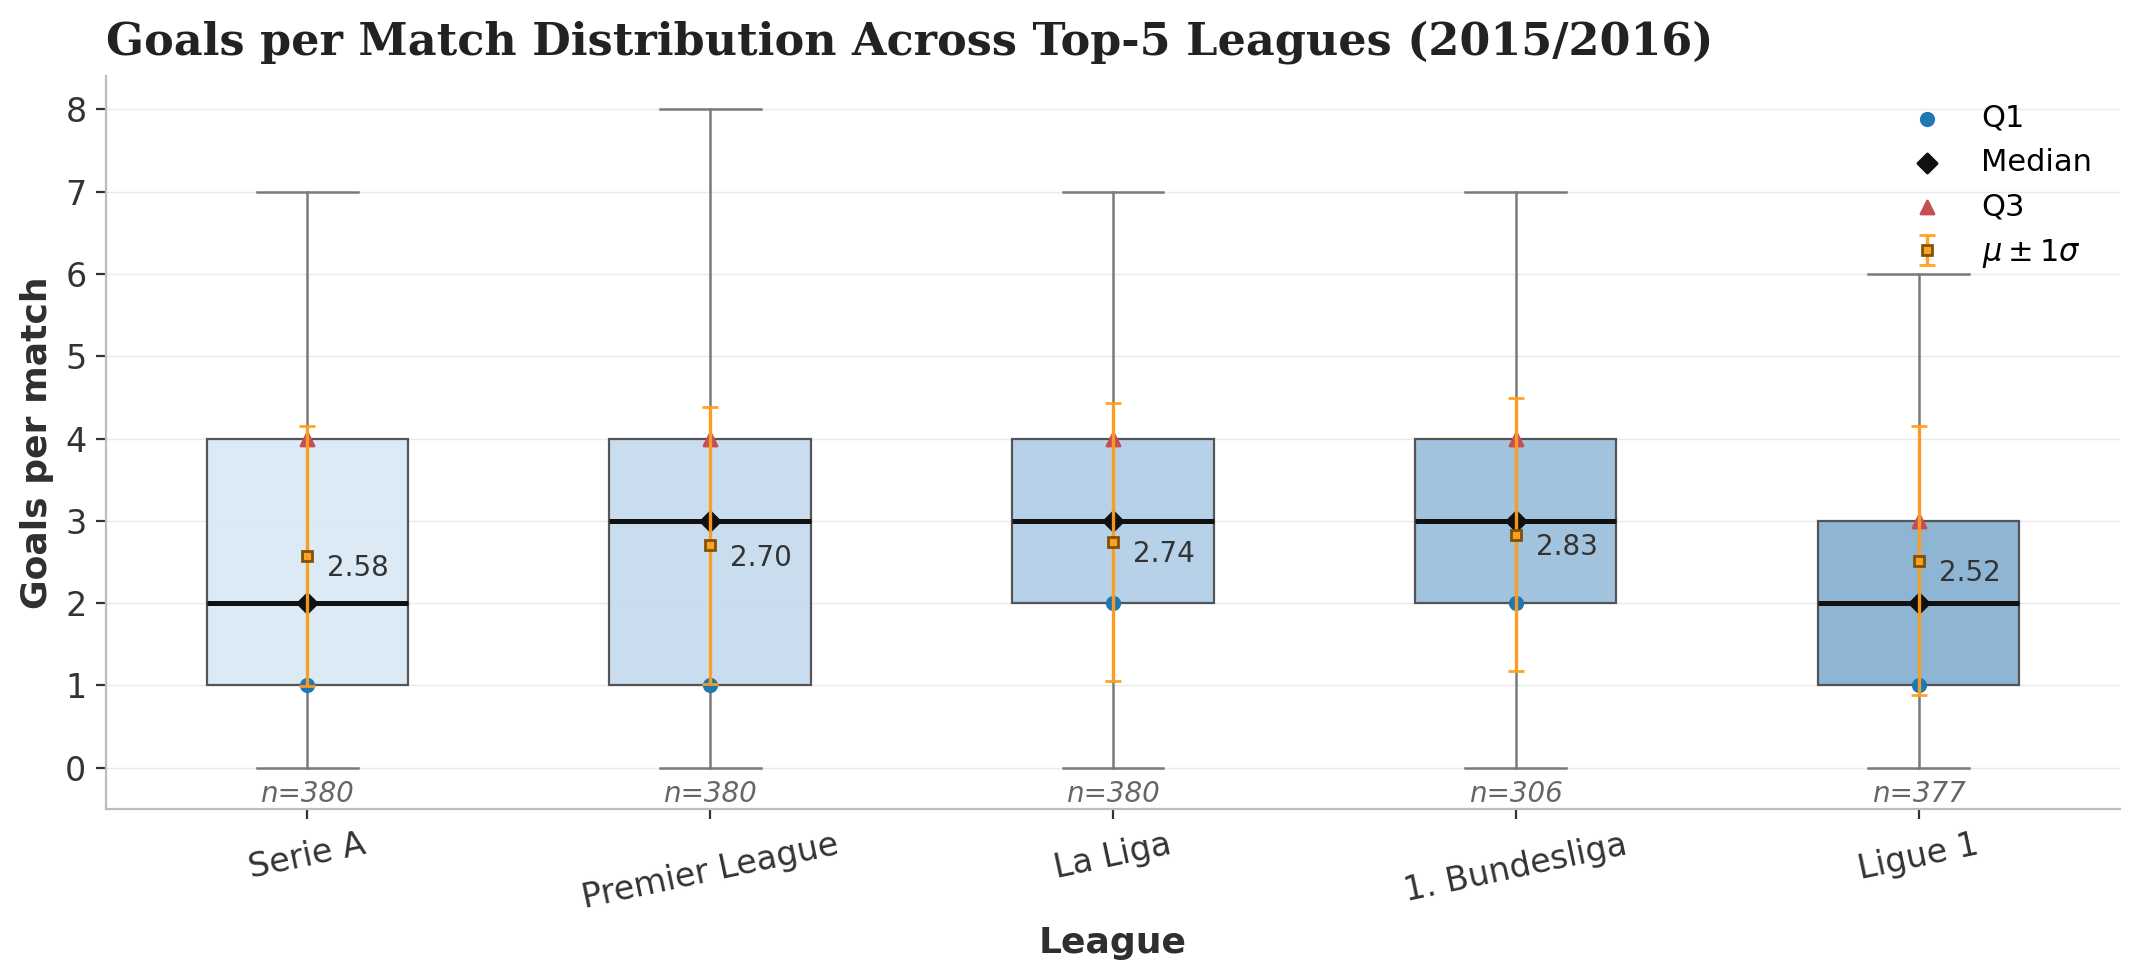

,q25,q50,q75,mean_goals,std_goals
competition_name,,,,,
Serie A,1.0,2.0,4.0,2.576,1.579
Premier League,1.0,3.0,4.0,2.700,1.685
La Liga,2.0,3.0,4.0,2.745,1.687
1. Bundesliga,2.0,3.0,4.0,2.830,1.659
Ligue 1,1.0,2.0,3.0,2.517,1.631


In [10]:
# Journal-style vertical boxplot with subtle quantile highlights
plot_data = per_game_top5.copy()
plot_data["competition_name"] = pd.Categorical(
    plot_data["competition_name"], categories=top5_ordered, ordered=True
)

quantiles = (
    plot_data.groupby("competition_name")["goals_in_game"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .reindex(top5_ordered)
)
quantiles.columns = ["q25", "q50", "q75"]

mean_std = (
    plot_data.groupby("competition_name")["goals_in_game"]
    .agg(["mean", "std"])
    .reindex(top5_ordered)
    .fillna(0)
    .rename(columns={"mean": "mean_goals", "std": "std_goals"})
)

fig, ax = plt.subplots(figsize=(10.8, 5), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

box_data = [
    plot_data.loc[plot_data["competition_name"] == league, "goals_in_game"].to_numpy()
    for league in top5_ordered
]

bp = ax.boxplot(
    box_data,
    patch_artist=True,
    labels=top5_ordered,
    showfliers=False,
    widths=0.50,
    medianprops={"color": "#111111", "linewidth": 1.8},
    whiskerprops={"color": "#7a7a7a", "linewidth": 0.9},
    capprops={"color": "#7a7a7a", "linewidth": 0.9},
    boxprops={"edgecolor": "#4d4d4d", "linewidth": 0.8},
)

fills = ["#dbe9f6", "#c7dcef", "#b3cfe8", "#9dc0dd", "#89b1d2"]
for box, color in zip(bp["boxes"], fills):
    box.set_facecolor(color)
    box.set_alpha(0.95)

x_pos = np.arange(1, len(top5_ordered) + 1)

# Quantile markers without connecting lines
ax.scatter(x_pos, quantiles["q25"], color="#1f77b4", s=20, marker="o", zorder=4, label="Q1")
ax.scatter(x_pos, quantiles["q50"], color="#111111", s=24, marker="D", zorder=4, label="Median")
ax.scatter(x_pos, quantiles["q75"], color="#c44e52", s=22, marker="^", zorder=4, label="Q3")

# Light guide from Q1 to Q3 to show IQR span per league
for xi, league in zip(x_pos, top5_ordered):
    ax.vlines(
        xi,
        quantiles.loc[league, "q25"],
        quantiles.loc[league, "q75"],
        color="#6c757d",
        linewidth=1.0,
        alpha=0.65,
        zorder=3,
    )

# Mean and mean ± std overlay
ax.errorbar(
    x_pos,
    mean_std["mean_goals"],
    yerr=mean_std["std_goals"],
    fmt="s",
    markersize=3.5,
    markerfacecolor="#ff9f1c",
    markeredgecolor="#7a4c00",
    ecolor="#ff9f1c",
    elinewidth=1.2,
    capsize=3,
    alpha=0.95,
    zorder=6,
    label="$\\mu \\pm 1 \\sigma$",
)

# Add mean value labels next to each marker
for xi, league in zip(x_pos, top5_ordered):
    mean_val = mean_std.loc[league, "mean_goals"]
    ax.text(
        xi + 0.05,
        mean_val - .15,
        f"{mean_val:.2f}",
        fontsize=10,
        color="#333333",
        #fontweight="semibold",
        va="center",
        zorder=7,
    )

# Add game count labels at the bottom of each box
game_counts = plot_data.groupby("competition_name").size().reindex(top5_ordered)
for xi, league in zip(x_pos, top5_ordered):
    game_count = game_counts[league]
    ax.text(
        xi,
        -0.15,
        f"n={int(game_count)}",
        ha="center",
        va="top",
        fontsize=10,
        color="#666666",
        style="italic",
    )

ax.set_title(
    f"Goals per Match Distribution Across Top-5 Leagues ({season_year})",
    fontsize=16,
    fontweight="semibold",
    color="#222222",
    loc="left",
    pad=8,
    fontfamily="DejaVu Serif",
)
ax.set_xlabel("League", fontsize=13, color="#2f2f2f", fontweight="semibold")
ax.set_ylabel("Goals per match", fontsize=13, color="#2f2f2f", fontweight="semibold")

ax.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.22, color="#9aa0a6")
ax.set_axisbelow(True)
ax.tick_params(axis="x", labelsize=12, colors="#333333", rotation=12)
ax.tick_params(axis="y", labelsize=12, colors="#333333")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#bdbdbd")
ax.spines["bottom"].set_color("#bdbdbd")
ax.set_ylim(bottom=-0.5)

ax.legend(loc="upper right", frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("goals_per_match_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

pd.concat([quantiles.round(3), mean_std.round(3)], axis=1)

In [11]:
# Kolmogorov-Smirnov tests: pairwise comparison of goal distributions across leagues
from itertools import combinations
from scipy.stats import ks_2samp

alpha = 0.05
ks_rows = []
for league_a, league_b in combinations(top5_ordered, 2):
    dist_a = per_game_top5.loc[per_game_top5["competition_name"] == league_a, "goals_in_game"].dropna().to_numpy()
    dist_b = per_game_top5.loc[per_game_top5["competition_name"] == league_b, "goals_in_game"].dropna().to_numpy()

    stat, p_value = ks_2samp(dist_a, dist_b, alternative="two-sided", method="auto")
    ks_rows.append({
        "league_a": league_a,
        "league_b": league_b,
        "n_a": len(dist_a),
        "n_b": len(dist_b),
        "ks_statistic": stat,
        "p_value": p_value,
    })

ks_results = pd.DataFrame(ks_rows).sort_values("p_value").reset_index(drop=True)

# Multiple-testing corrections
m = len(ks_results)
p = ks_results["p_value"].to_numpy(dtype=float)

# Bonferroni: controls family-wise error rate
ks_results["p_bonferroni"] = np.minimum(p * m, 1.0)
ks_results["significant_bonferroni"] = ks_results["p_bonferroni"] < alpha

# Benjamini-Hochberg (FDR)
order = np.argsort(p)
p_sorted = p[order]
ranks = np.arange(1, m + 1)
p_bh_sorted = p_sorted * m / ranks

# Enforce monotonicity from the back
p_bh_sorted = np.minimum.accumulate(p_bh_sorted[::-1])[::-1]
p_bh_sorted = np.clip(p_bh_sorted, 0.0, 1.0)

p_bh = np.empty_like(p_bh_sorted)
p_bh[order] = p_bh_sorted
ks_results["p_bh_fdr"] = p_bh
ks_results["significant_bh_fdr"] = ks_results["p_bh_fdr"] < alpha

ks_results.round(4)

,league_a,league_b,n_a,n_b,ks_statistic,p_value,p_bonferroni,significant_bonferroni,p_bh_fdr,significant_bh_fdr
0,1. Bundesliga,Ligue 1,306,377,0.1185,0.0156,0.1563,False,0.1563,False
1,Premier League,Ligue 1,380,377,0.0886,0.0939,0.9394,False,0.4697,False
2,Serie A,1. Bundesliga,380,306,0.0851,0.1591,1.0000,False,0.5302,False
3,La Liga,Ligue 1,380,377,0.0755,0.2152,1.0000,False,0.5380,False
4,Serie A,Premier League,380,380,0.0553,0.6081,1.0000,False,0.9796,False
5,La Liga,1. Bundesliga,380,306,0.0504,0.7569,1.0000,False,0.9796,False
6,Serie A,La Liga,380,380,0.0421,0.8898,1.0000,False,0.9796,False
7,Premier League,1. Bundesliga,380,306,0.0429,0.8956,1.0000,False,0.9796,False
8,Serie A,Ligue 1,380,377,0.0334,0.9771,1.0000,False,0.9796,False
9,Premier League,La Liga,380,380,0.0342,0.9796,1.0000,False,0.9796,False


In [12]:
# Global distribution test across all leagues (H0: all come from the same distribution)
from scipy.stats import anderson_ksamp

alpha = 0.1
samples = [
    per_game_top5.loc[per_game_top5["competition_name"] == league, "goals_in_game"].dropna().to_numpy()
    for league in top5_ordered
]

# Keep only non-empty league samples for a valid k-sample test
valid_pairs = [(league, s) for league, s in zip(top5_ordered, samples) if len(s) > 0]
valid_leagues = [league for league, _ in valid_pairs]
valid_samples = [s for _, s in valid_pairs]

if len(valid_samples) < 2:
    print("Not enough non-empty league samples to run a global distribution test.")
else:
    ad_result = anderson_ksamp(valid_samples)
    p_value = float(ad_result.significance_level)
    test_stat = float(ad_result.statistic)

    global_test_summary = pd.DataFrame(
        [{
            "test": "Anderson-Darling k-sample",
            "null_hypothesis": "All league goal distributions are identical",
            "n_groups": len(valid_samples),
            "groups_tested": ", ".join(valid_leagues),
            "statistic": round(test_stat, 4),
            "p_value_approx": round(p_value, 6),
            "alpha": alpha,
            "reject_h0": p_value < alpha,
            "decision": "Reject H0 (at least one distribution differs)" if p_value < alpha else "Fail to reject H0 (no evidence of difference)",
        }]
    )

    display(global_test_summary)
    print("Note: scipy.stats.anderson_ksamp returns an approximate p-value that may be capped/floored by SciPy.")

,test,null_hypothesis,n_groups,groups_tested,statistic,p_value_approx,alpha,reject_h0,decision
0,Anderson-Darling k-sample,All league goal distributions are identical,5,"Serie A, Premier League, La Liga, 1. Bundeslig...",1.6953,0.063023,0.1,True,Reject H0 (at least one distribution differs)


Note: scipy.stats.anderson_ksamp returns an approximate p-value that may be capped/floored by SciPy.


In [13]:
# Kruskal-Wallis test across all leagues (H0: same distribution location across groups)
from scipy.stats import kruskal

alpha = 0.1
kw_samples = [
    per_game_top5.loc[per_game_top5["competition_name"] == league, "goals_in_game"].dropna().to_numpy()
    for league in top5_ordered
]

valid_pairs_kw = [(league, s) for league, s in zip(top5_ordered, kw_samples) if len(s) > 0]
valid_leagues_kw = [league for league, _ in valid_pairs_kw]
valid_samples_kw = [s for _, s in valid_pairs_kw]

if len(valid_samples_kw) < 2:
    print("Not enough non-empty league samples to run Kruskal-Wallis.")
else:
    h_stat, p_value_kw = kruskal(*valid_samples_kw)

    n_total = int(sum(len(s) for s in valid_samples_kw))
    k_groups = len(valid_samples_kw)
    epsilon_sq = (h_stat - k_groups + 1) / (n_total - k_groups) if n_total > k_groups else np.nan

    kw_summary = pd.DataFrame(
        [{
            "test": "Kruskal-Wallis H",
            "null_hypothesis": "All leagues have the same distribution location",
            "n_groups": k_groups,
            "groups_tested": ", ".join(valid_leagues_kw),
            "H_statistic": round(float(h_stat), 4),
            "p_value": round(float(p_value_kw), 6),
            "alpha": alpha,
            "reject_h0": float(p_value_kw) < alpha,
            "epsilon_squared": round(float(epsilon_sq), 4) if pd.notna(epsilon_sq) else np.nan,
            "decision": "Reject H0 (at least one league differs)" if float(p_value_kw) < alpha else "Fail to reject H0",
        }]
    )

    display(kw_summary)

    print("Interpretation: Kruskal-Wallis is rank-based and mainly tests differences in central tendency, not full-shape equality.")

,test,null_hypothesis,n_groups,groups_tested,H_statistic,p_value,alpha,reject_h0,epsilon_squared,decision
0,Kruskal-Wallis H,All leagues have the same distribution location,5,"Serie A, Premier League, La Liga, 1. Bundeslig...",9.1069,0.058482,0.1,True,0.0028,Reject H0 (at least one league differs)


Interpretation: Kruskal-Wallis is rank-based and mainly tests differences in central tendency, not full-shape equality.


In [14]:
# One-way ANOVA across all leagues (H0: equal means across groups)
from scipy.stats import f_oneway

alpha = 0.1
anova_samples = [
    per_game_top5.loc[per_game_top5["competition_name"] == league, "goals_in_game"].dropna().to_numpy()
    for league in top5_ordered
]

valid_pairs_anova = [(league, s) for league, s in zip(top5_ordered, anova_samples) if len(s) > 0]
valid_leagues_anova = [league for league, _ in valid_pairs_anova]
valid_samples_anova = [s for _, s in valid_pairs_anova]

if len(valid_samples_anova) < 2:
    print("Not enough non-empty league samples to run ANOVA.")
else:
    f_stat, p_value_anova = f_oneway(*valid_samples_anova)

    all_values = np.concatenate(valid_samples_anova)
    grand_mean = float(np.mean(all_values))
    ss_between = sum(len(s) * (float(np.mean(s)) - grand_mean) ** 2 for s in valid_samples_anova)
    ss_total = float(np.sum((all_values - grand_mean) ** 2))
    eta_squared = (ss_between / ss_total) if ss_total > 0 else np.nan

    anova_summary = pd.DataFrame(
        [{
            "test": "One-way ANOVA",
            "null_hypothesis": "All leagues have the same mean goals per game",
            "n_groups": len(valid_samples_anova),
            "groups_tested": ", ".join(valid_leagues_anova),
            "F_statistic": round(float(f_stat), 4),
            "p_value": round(float(p_value_anova), 6),
            "alpha": alpha,
            "reject_h0": float(p_value_anova) < alpha,
            "eta_squared": round(float(eta_squared), 4) if pd.notna(eta_squared) else np.nan,
            "decision": "Reject H0 (at least one mean differs)" if float(p_value_anova) < alpha else "Fail to reject H0",
        }]
    )

    display(anova_summary)

    print("Note: ANOVA targets mean differences and assumes independent observations, approximate normality, and similar variances.")

,test,null_hypothesis,n_groups,groups_tested,F_statistic,p_value,alpha,reject_h0,eta_squared,decision
0,One-way ANOVA,All leagues have the same mean goals per game,5,"Serie A, Premier League, La Liga, 1. Bundeslig...",2.0641,0.083097,0.1,True,0.0045,Reject H0 (at least one mean differs)


Note: ANOVA targets mean differences and assumes independent observations, approximate normality, and similar variances.


C:\Users\Antonio\AppData\Local\Temp\ipykernel_18384\3550538461.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby("competition_name")["goals_in_game"]
C:\Users\Antonio\AppData\Local\Temp\ipykernel_18384\3550538461.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data.groupby("competition_name")["goals_in_game"]


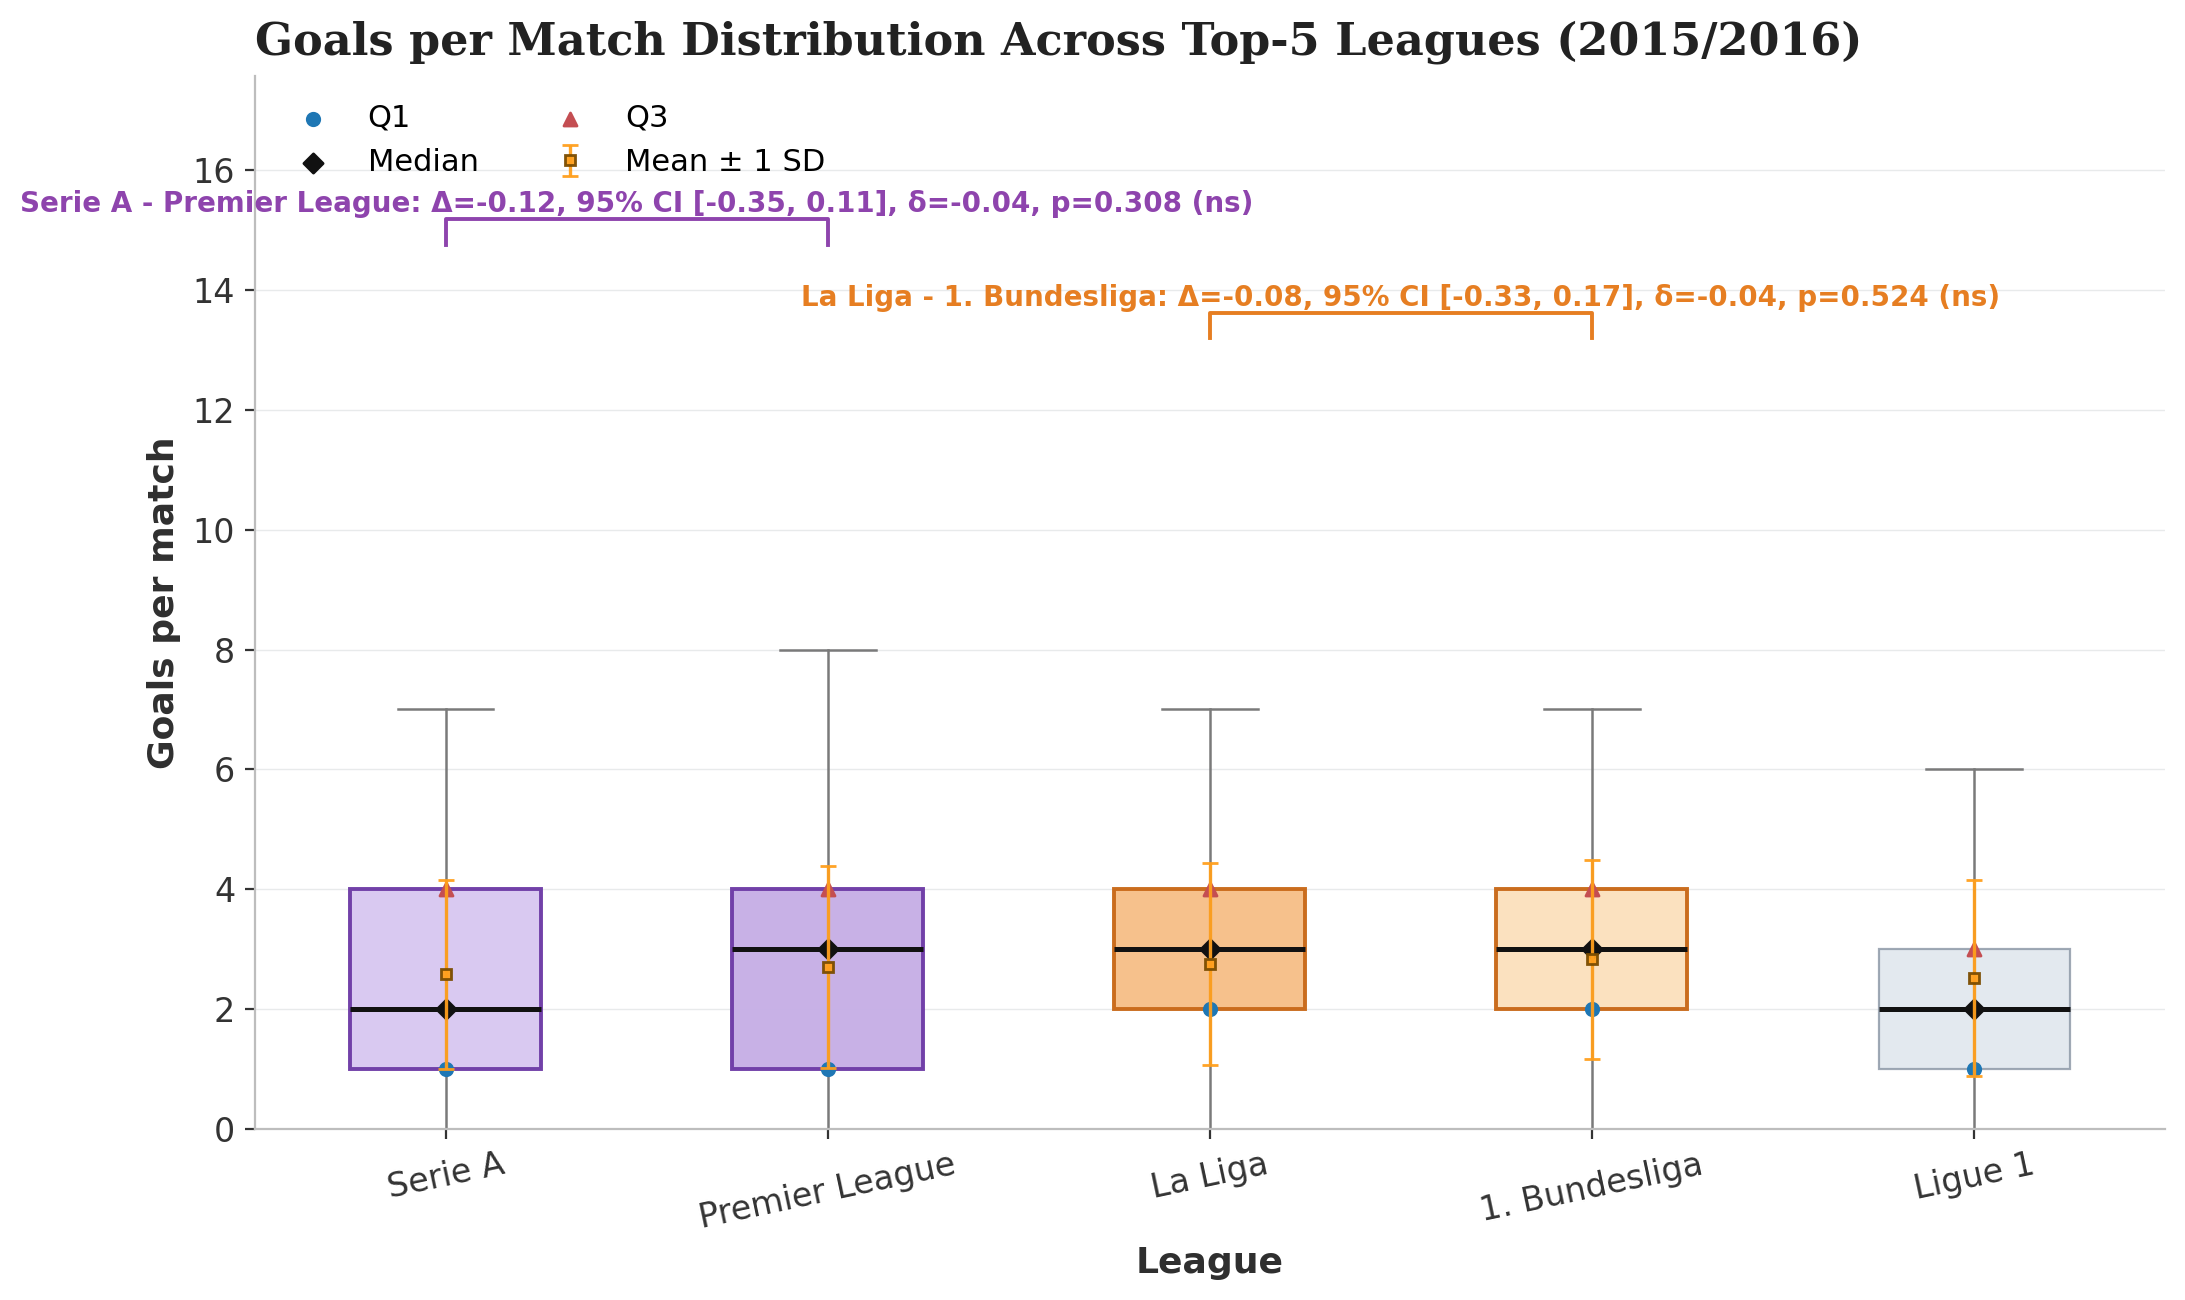

,pair,delta_mean,ci_low,ci_high,cliffs_delta,p_value_perm,significance
0,La Liga - 1. Bundesliga,-0.083,-0.334,0.171,-0.044,0.524,ns
1,Serie A - Premier League,-0.122,-0.350,0.113,-0.038,0.308,ns


In [15]:
# Pair-focused publication plot: targeted league contrasts with statistical annotations
from numpy.random import default_rng

plot_data = per_game_top5.copy()
plot_data["competition_name"] = pd.Categorical(
    plot_data["competition_name"], categories=top5_ordered, ordered=True
)

quantiles = (
    plot_data.groupby("competition_name")["goals_in_game"]
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .reindex(top5_ordered)
)
quantiles.columns = ["q25", "q50", "q75"]

mean_std = (
    plot_data.groupby("competition_name")["goals_in_game"]
    .agg(["mean", "std"])
    .reindex(top5_ordered)
    .fillna(0)
    .rename(columns={"mean": "mean_goals", "std": "std_goals"})
)

def bootstrap_mean_diff(a, b, n_boot=5000, seed=42):
    rng = default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        a_s = rng.choice(a, size=a.size, replace=True)
        b_s = rng.choice(b, size=b.size, replace=True)
        boot[i] = a_s.mean() - b_s.mean()
    return boot.mean(), np.percentile(boot, [2.5, 97.5])

def cliffs_delta(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    gt = (a[:, None] > b[None, :]).sum()
    lt = (a[:, None] < b[None, :]).sum()
    return (gt - lt) / (a.size * b.size)

def permutation_pvalue_mean_diff(a, b, n_perm=6000, seed=42):
    rng = default_rng(seed)
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    observed = abs(a.mean() - b.mean())
    pooled = np.concatenate([a, b])
    n_a = a.size
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        perm_diff = abs(pooled[:n_a].mean() - pooled[n_a:].mean())
        if perm_diff >= observed:
            count += 1
    return (count + 1) / (n_perm + 1)

def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

def add_significance_bracket(ax, x1, x2, y, h, text, color):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], color=color, lw=1.4, clip_on=False)
    ax.text(
        (x1 + x2) / 2,
        y + h + 0.02,
        text,
        ha="center",
        va="bottom",
        fontsize=10,
        color=color,
        fontweight="semibold",
    )

pair_specs = [
    ("La Liga", "1. Bundesliga", "#E67E22"),
    ("Serie A", "Premier League", "#8E44AD"),
]
highlight_leagues = {league for a, b, _ in pair_specs for league in [a, b]}

fill_map = {
    "La Liga": "#F6C08A",
    "1. Bundesliga": "#FBE1BE",
    "Serie A": "#D9C8F1",
    "Premier League": "#C7B0E6",
    "Ligue 1": "#DDE4EC",
}
edge_map = {
    "La Liga": "#C96A1A",
    "1. Bundesliga": "#C96A1A",
    "Serie A": "#6F3DA7",
    "Premier League": "#6F3DA7",
    "Ligue 1": "#8894A3",
}

fig, ax = plt.subplots(figsize=(11.2, 6.6), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

box_data = [
    plot_data.loc[plot_data["competition_name"] == league, "goals_in_game"].to_numpy()
    for league in top5_ordered
]

bp = ax.boxplot(
    box_data,
    patch_artist=True,
    labels=top5_ordered,
    showfliers=False,
    widths=0.50,
    medianprops={"color": "#111111", "linewidth": 1.8},
    whiskerprops={"color": "#7a7a7a", "linewidth": 0.9},
    capprops={"color": "#7a7a7a", "linewidth": 0.9},
    boxprops={"edgecolor": "#4d4d4d", "linewidth": 0.8},
)

for box, league in zip(bp["boxes"], top5_ordered):
    box.set_facecolor(fill_map[league])
    box.set_alpha(0.98 if league in highlight_leagues else 0.8)
    box.set_edgecolor(edge_map[league])
    box.set_linewidth(1.4 if league in highlight_leagues else 0.8)

x_pos = np.arange(1, len(top5_ordered) + 1)

# Quantile markers and IQR guides
ax.scatter(x_pos, quantiles["q25"], color="#1f77b4", s=20, marker="o", zorder=4, label="Q1")
ax.scatter(x_pos, quantiles["q50"], color="#111111", s=24, marker="D", zorder=5, label="Median")
ax.scatter(x_pos, quantiles["q75"], color="#c44e52", s=22, marker="^", zorder=4, label="Q3")
for xi, league in zip(x_pos, top5_ordered):
    ax.vlines(
        xi,
        quantiles.loc[league, "q25"],
        quantiles.loc[league, "q75"],
        color="#6c757d",
        linewidth=0.9,
        alpha=0.65,
        zorder=3,
    )

# Mean and mean +- std
ax.errorbar(
    x_pos,
    mean_std["mean_goals"],
    yerr=mean_std["std_goals"],
    fmt="s",
    markersize=3.5,
    markerfacecolor="#ff9f1c",
    markeredgecolor="#7a4c00",
    ecolor="#ff9f1c",
    elinewidth=1.2,
    capsize=3,
    alpha=0.95,
    zorder=6,
    label="Mean ± 1 SD",
)

league_to_x = {league: i + 1 for i, league in enumerate(top5_ordered)}
y_max_data = float(plot_data["goals_in_game"].max())
y_min_data = float(plot_data["goals_in_game"].min())
y_span = max(1e-6, y_max_data - y_min_data)
bracket_base = y_max_data + 0.10 * y_span
bracket_step = 0.13 * y_span
bracket_h = 0.035 * y_span

pair_rows = []
for i, (league_a, league_b, color) in enumerate(pair_specs):
    vals_a = plot_data.loc[plot_data["competition_name"] == league_a, "goals_in_game"].to_numpy()
    vals_b = plot_data.loc[plot_data["competition_name"] == league_b, "goals_in_game"].to_numpy()

    delta_mean, ci = bootstrap_mean_diff(vals_a, vals_b, n_boot=5000, seed=42 + i)
    effect = cliffs_delta(vals_a, vals_b)
    p_val = permutation_pvalue_mean_diff(vals_a, vals_b, n_perm=6000, seed=202 + i)
    stars = p_to_stars(p_val)

    text = (
        f"{league_a} - {league_b}: Δ={delta_mean:.2f}, "
        f"95% CI [{ci[0]:.2f}, {ci[1]:.2f}], "
        f"δ={effect:.2f}, p={p_val:.3f} ({stars})"
    )
    y = bracket_base + i * bracket_step
    add_significance_bracket(ax, league_to_x[league_a], league_to_x[league_b], y, bracket_h, text, color)

    pair_rows.append({
        "pair": f"{league_a} - {league_b}",
        "delta_mean": delta_mean,
        "ci_low": ci[0],
        "ci_high": ci[1],
        "cliffs_delta": effect,
        "p_value_perm": p_val,
        "significance": stars,
    })

ax.set_title(
    f"Goals per Match Distribution Across Top-5 Leagues ({season_year})",
    fontsize=16,
    fontweight="semibold",
    color="#222222",
    loc="left",
    pad=8,
    fontfamily="DejaVu Serif",
)
ax.set_xlabel("League", fontsize=13, color="#2f2f2f", fontweight="semibold")
ax.set_ylabel("Goals per match", fontsize=13, color="#2f2f2f", fontweight="semibold")
ax.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.22, color="#9aa0a6")
ax.set_axisbelow(True)
ax.tick_params(axis="x", labelsize=12, colors="#333333", rotation=12)
ax.tick_params(axis="y", labelsize=12, colors="#333333")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#bdbdbd")
ax.spines["bottom"].set_color("#bdbdbd")
ax.set_ylim(bottom=0, top=bracket_base + (len(pair_specs) + 0.8) * bracket_step)

ax.legend(loc="upper left", frameon=False, fontsize=11, ncol=2)

plt.tight_layout()
plt.show()

pairwise_summary = pd.DataFrame(pair_rows).round(3)
pairwise_summary

In [16]:
league_stats = per_game_top5.groupby("competition_name").agg(
    num_games=("game_id", "count"),
    total_goals=("goals_in_game", "sum"),
    avg_goals=("goals_in_game", "mean"),
    std_goals=("goals_in_game", "std"),
).reset_index()

league_stats["std_goals"] = league_stats["std_goals"].fillna(0)
league_stats["competition_name"] = pd.Categorical(league_stats["competition_name"], categories=top5_ordered, ordered=True)
league_stats = league_stats.sort_values("competition_name")


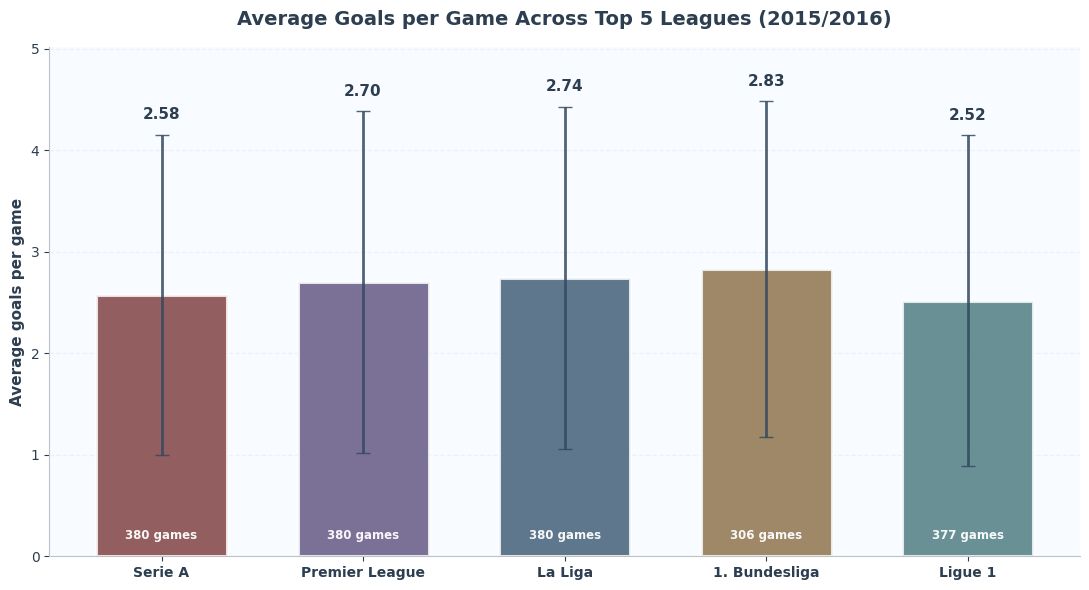

In [17]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_facecolor("#f8fbff")
ax.grid(axis="y", linestyle="--", linewidth=0.9, alpha=0.3, color="#d0dce8")
ax.set_axisbelow(True)

league_colors = {
    "Serie A": "#7D3C3C",
    "La Liga": "#3D5A73",
    "1. Bundesliga": "#8B6F47",
    "Premier League": "#5F5380",
    "Ligue 1": "#4A7A7E",
}

colors = [league_colors[league] for league in league_stats["competition_name"]]

bars = ax.bar(
    range(len(league_stats)),
    league_stats["avg_goals"],
    yerr=league_stats["std_goals"],
    color=colors,
    alpha=0.82,
    edgecolor="white",
    linewidth=2.2,
    error_kw={"elinewidth": 2.0, "capsize": 5, "ecolor": "#34495e", "alpha": 0.85},
    width=0.65,
)

for i, (bar, row) in enumerate(zip(bars, league_stats.itertuples())):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + row.std_goals + 0.12,
        f"{row.avg_goals:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#2c3e50",
    )
    # Game count label in the middle of bar.
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        0.2, #height / 2,
        f"{int(row.num_games)} games",
        ha="center",
        va="center",
        fontsize=8.5,
        color="white",
        fontweight="bold",
        alpha=0.95,
    )

ax.set_xticks(range(len(league_stats)))
ax.set_xticklabels(
    league_stats["competition_name"],
    fontsize=11,
    fontweight="semibold",
    rotation=0,
)

ax.set_title(
    f"Average Goals per Game Across Top 5 Leagues ({season_year})",
    fontsize=14,
    fontweight="bold",
    pad=16,
    color="#2c3e50",
)
ax.set_ylabel("Average goals per game", fontsize=11, fontweight="semibold", color="#2c3e50")

y_max = league_stats["avg_goals"].max() + league_stats["std_goals"].max() + 0.5
ax.set_ylim(0, y_max)

# Clean up spines.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#bdc3c7")
ax.spines["bottom"].set_color("#bdc3c7")
ax.tick_params(axis="both", which="major", labelsize=10, colors="#2c3e50")

plt.tight_layout()
plt.show()

# Concept Shift

In [18]:
def mark_true_goal_actions(df):
    out = df.copy()

    sort_cols = [c for c in ["game_id", "period_id", "time_seconds", "action_id"] if c in out.columns]
    out = out.sort_values(sort_cols).copy()
    is_true_goal_action = pd.Series(False, index=out.index)

    if not is_true_goal_action.any():
        shot_like_actions = {"shot", "shot_penalty", "shot_freekick"}
        is_shot_like = out["type_name"].astype(str).isin(shot_like_actions) if "type_name" in out.columns else pd.Series(False, index=out.index)

        if "result_name" in out.columns:
            is_goal_result = out["result_name"].astype(str).isin({"success", "owngoal"})
            is_true_goal_action = is_shot_like & is_goal_result
        elif "result_id" in out.columns:
            is_true_goal_action = is_shot_like & out["result_id"].eq(1)

    out["is_true_goal_action"] = is_true_goal_action.fillna(False)
    return out


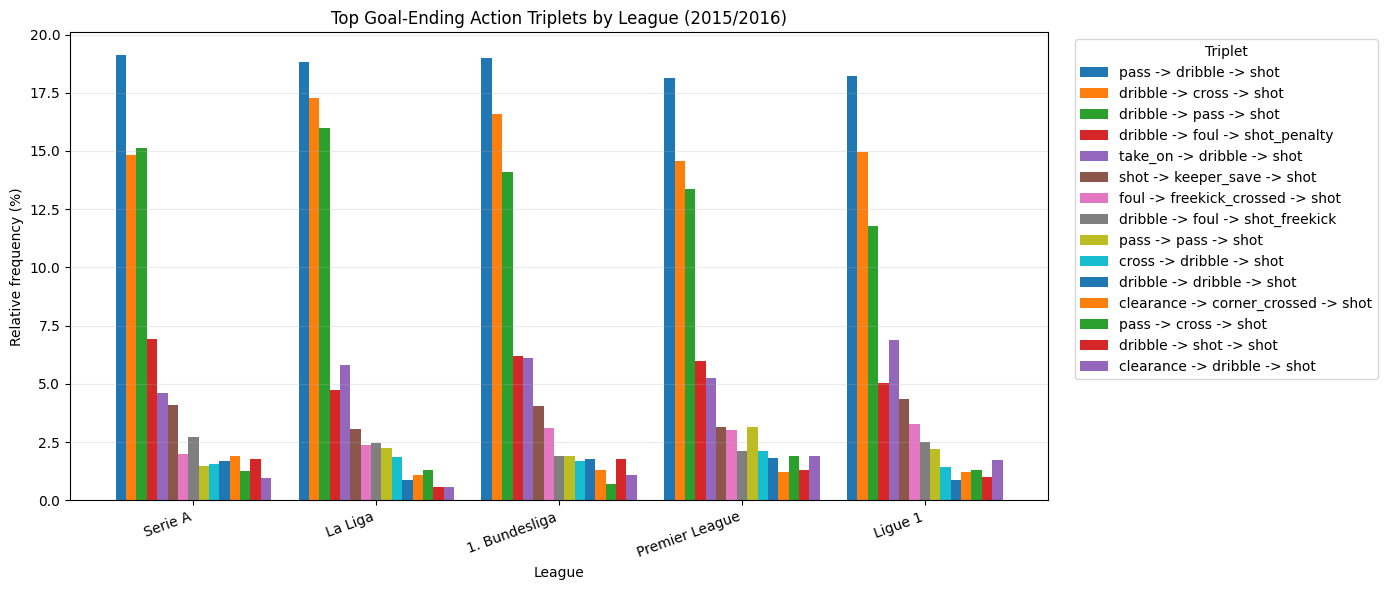

In [19]:
selected_season = "2015/2016"

top5_leagues = [
    "Serie A",
    "La Liga",
    "1. Bundesliga",
    "Premier League",
    "Ligue 1",
]

triplet_data = full_data.loc[
    full_data["season_name"].astype(str).eq(selected_season)
    & full_data["competition_name"].isin(top5_leagues)
].copy()


# Ensure correct temporal order inside each game before creating lagged actions.
order_cols = [c for c in ["game_id", "period_id", "time_seconds", "action_id"] if c in triplet_data.columns]
triplet_data = triplet_data.sort_values(order_cols).copy()
triplet_data = mark_true_goal_actions(triplet_data)

triplet_data["type_t-1"] = triplet_data.groupby("game_id")["type_name"].shift(1)
triplet_data["type_t-2"] = triplet_data.groupby("game_id")["type_name"].shift(2)

goal_triplets = triplet_data.loc[
    triplet_data["is_true_goal_action"]
    & triplet_data["type_t-1"].notna()
    & triplet_data["type_t-2"].notna()
].copy()

goal_triplets["triplet"] = (
    goal_triplets["type_t-2"] + " -> " + goal_triplets["type_t-1"] + " -> " + goal_triplets["type_name"]
)

triplet_counts = (
    goal_triplets.groupby(["competition_name", "triplet"]).size().rename("count").reset_index()
)
triplet_counts["share_%"] = (
    triplet_counts.groupby("competition_name")["count"]
    .transform(lambda x: 100 * x / x.sum())
    .round(3)
)

triplet_cmp = (
    triplet_counts.pivot_table(
        index="triplet",
        columns="competition_name",
        values="share_%",
        fill_value=0,
    )
    .reindex(columns=top5_leagues, fill_value=0)
)
triplet_cmp = triplet_cmp.loc[triplet_cmp.mean(axis=1).sort_values(ascending=False).index]

top_n_triplets = 15
plot_table = triplet_cmp.head(top_n_triplets)

fig, ax = plt.subplots(figsize=(14, 6))
plot_table.T.plot(kind="bar", ax=ax, width=0.85)
ax.set_title(f"Top Goal-Ending Action Triplets by League ({selected_season})")
ax.set_xlabel("League")
ax.set_ylabel("Relative frequency (%)")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Triplet", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

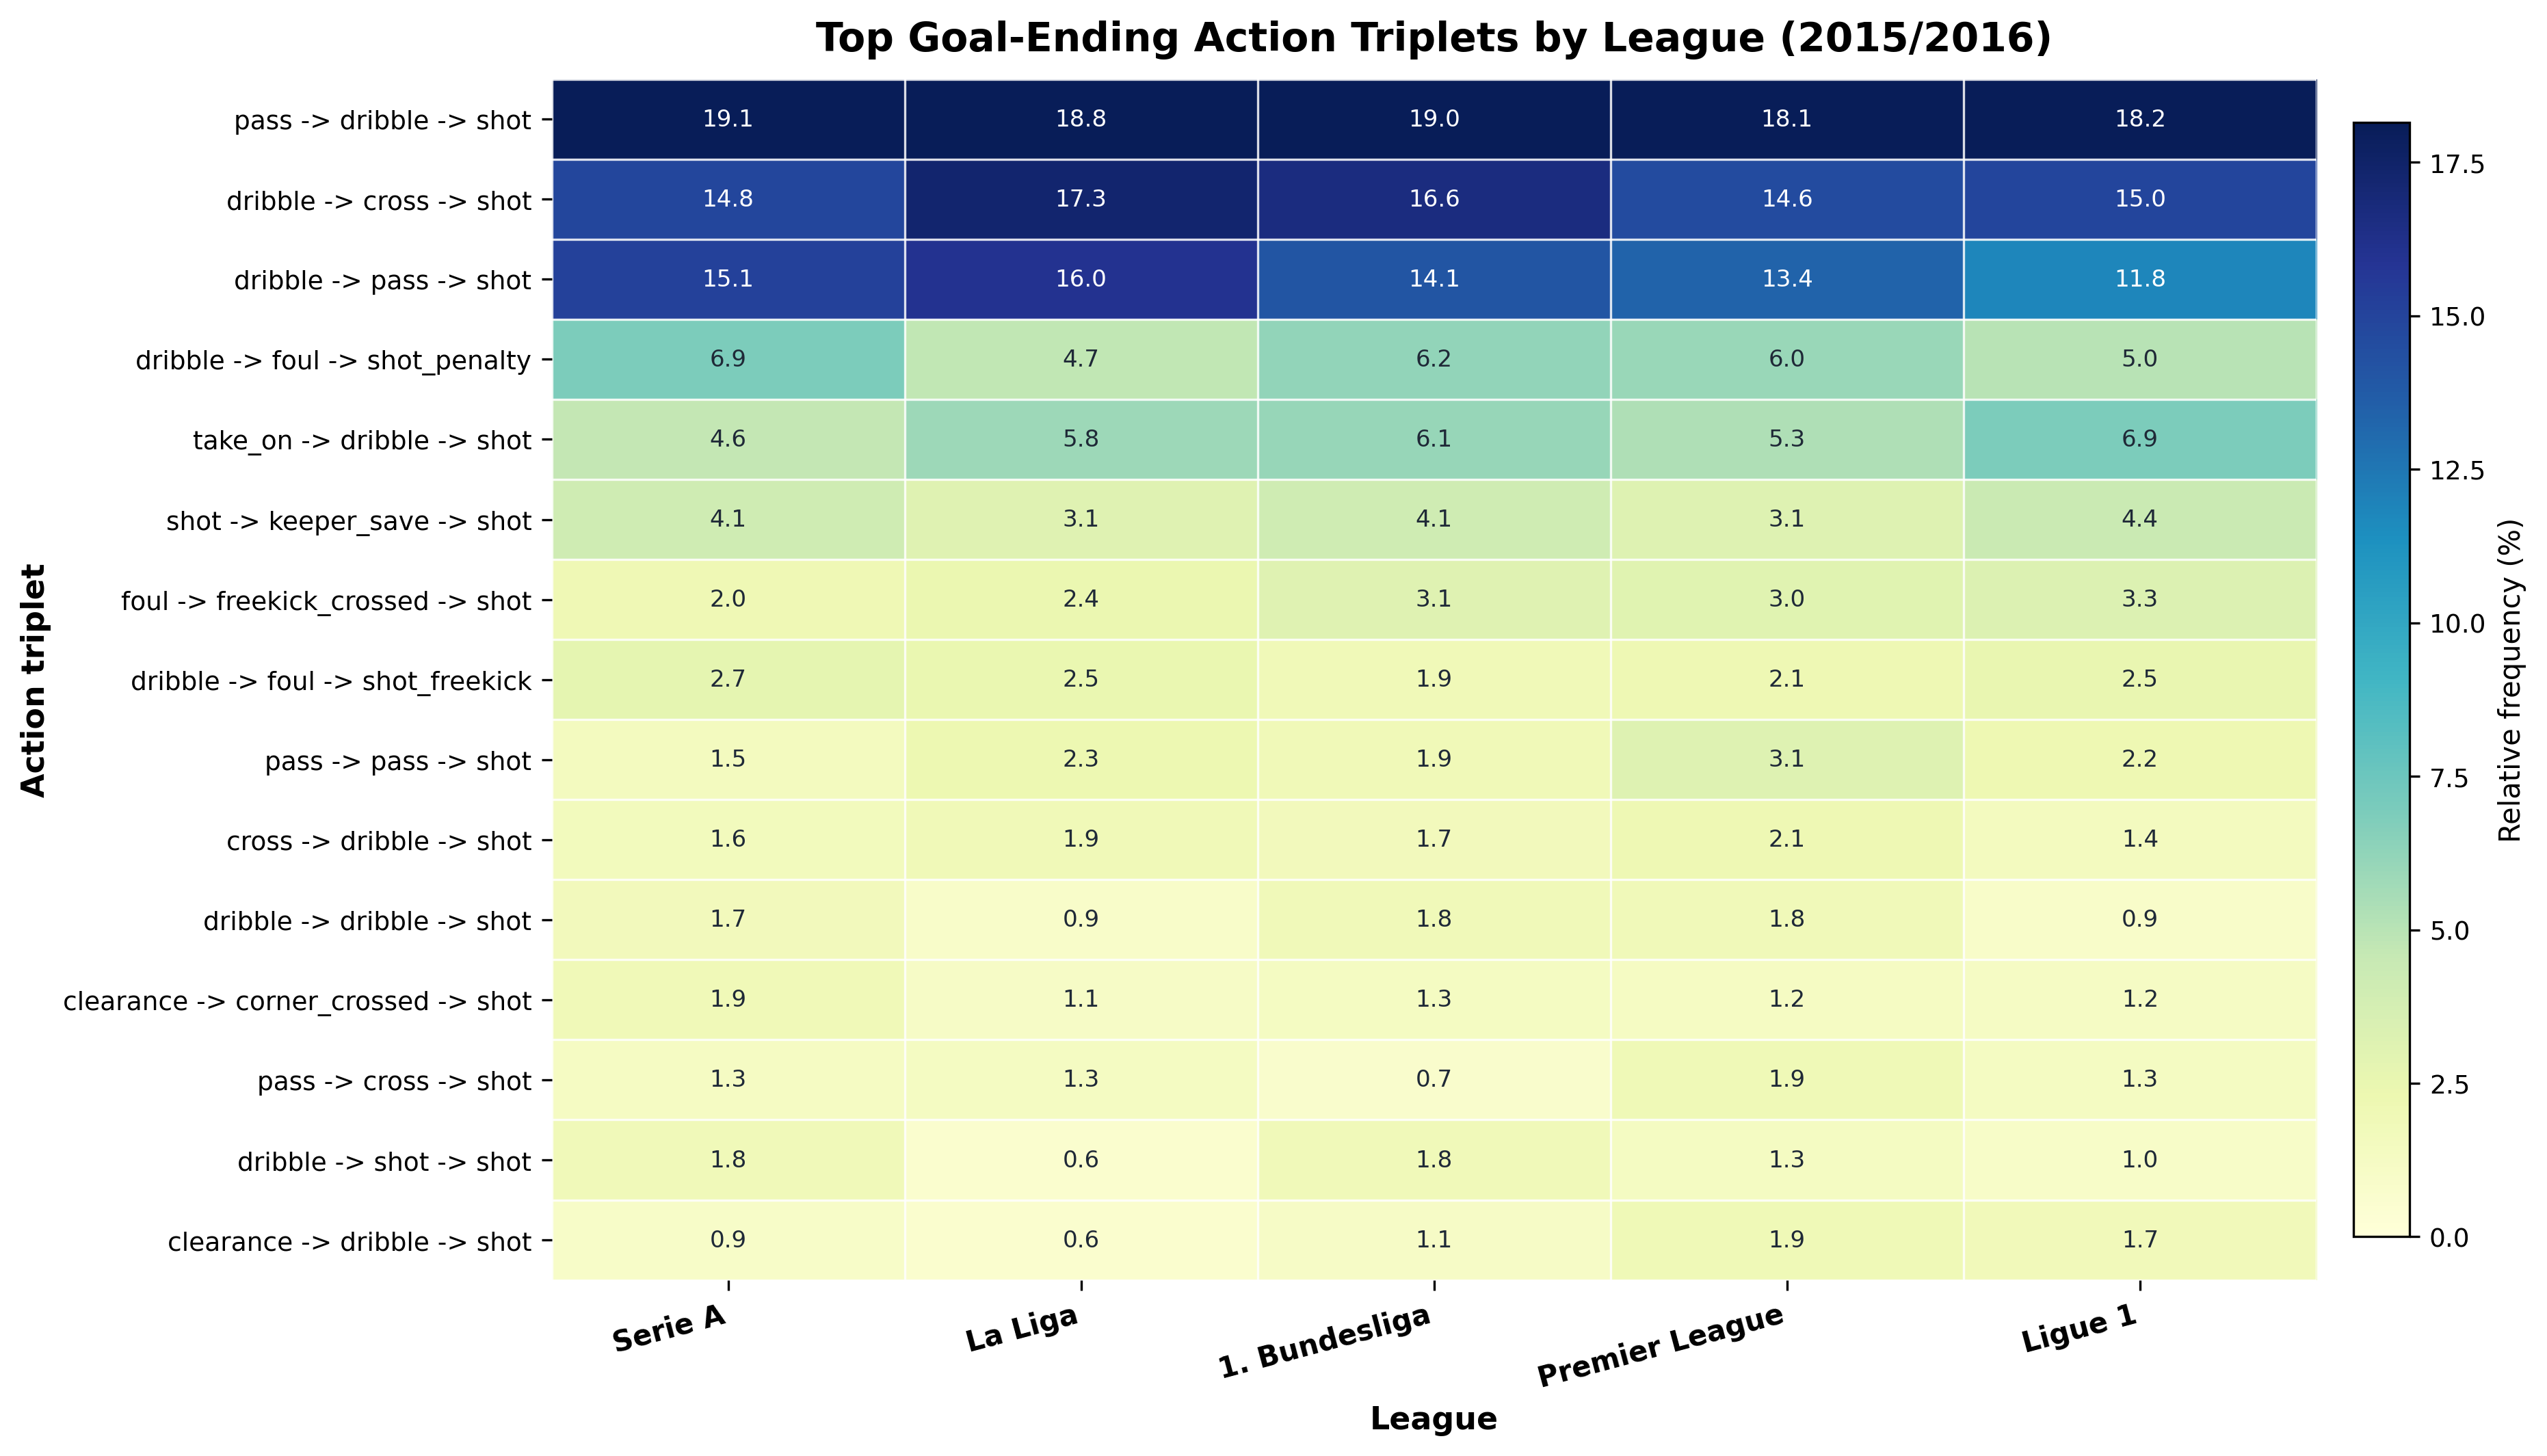

In [20]:
# Publication-style heatmap for top goal-ending triplets
heatmap_data = plot_table.copy()

y_labels = [idx for idx in heatmap_data.index]
x_labels = heatmap_data.columns.tolist()

fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=300)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# Robust upper bound prevents one large value from dominating the colormap scale
vmax = np.percentile(heatmap_data.to_numpy(), 95)
im = ax.imshow(
    heatmap_data.to_numpy(),
    cmap="YlGnBu",
    aspect="auto",
    vmin=0,
    vmax=vmax,
)

# Axis labels and ticks
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, fontsize=10, fontweight="semibold", rotation=15, ha="right")
ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=9)

ax.set_title(
    f"Top Goal-Ending Action Triplets by League ({selected_season})",
    fontsize=14,
    fontweight="semibold",
    pad=10,
)
ax.set_xlabel("League", fontsize=11, fontweight="semibold")
ax.set_ylabel("Action triplet", fontsize=11, fontweight="semibold")

# Annotate each cell with percentage values for paper readability
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.iat[i, j]
        text_color = "white" if val > 0.55 * vmax else "#1f2937"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8.2, color=text_color)

# Subtle frame and grid-like separators
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks(np.arange(-0.5, len(x_labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(y_labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8, alpha=0.85)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Relative frequency (%)", fontsize=10)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

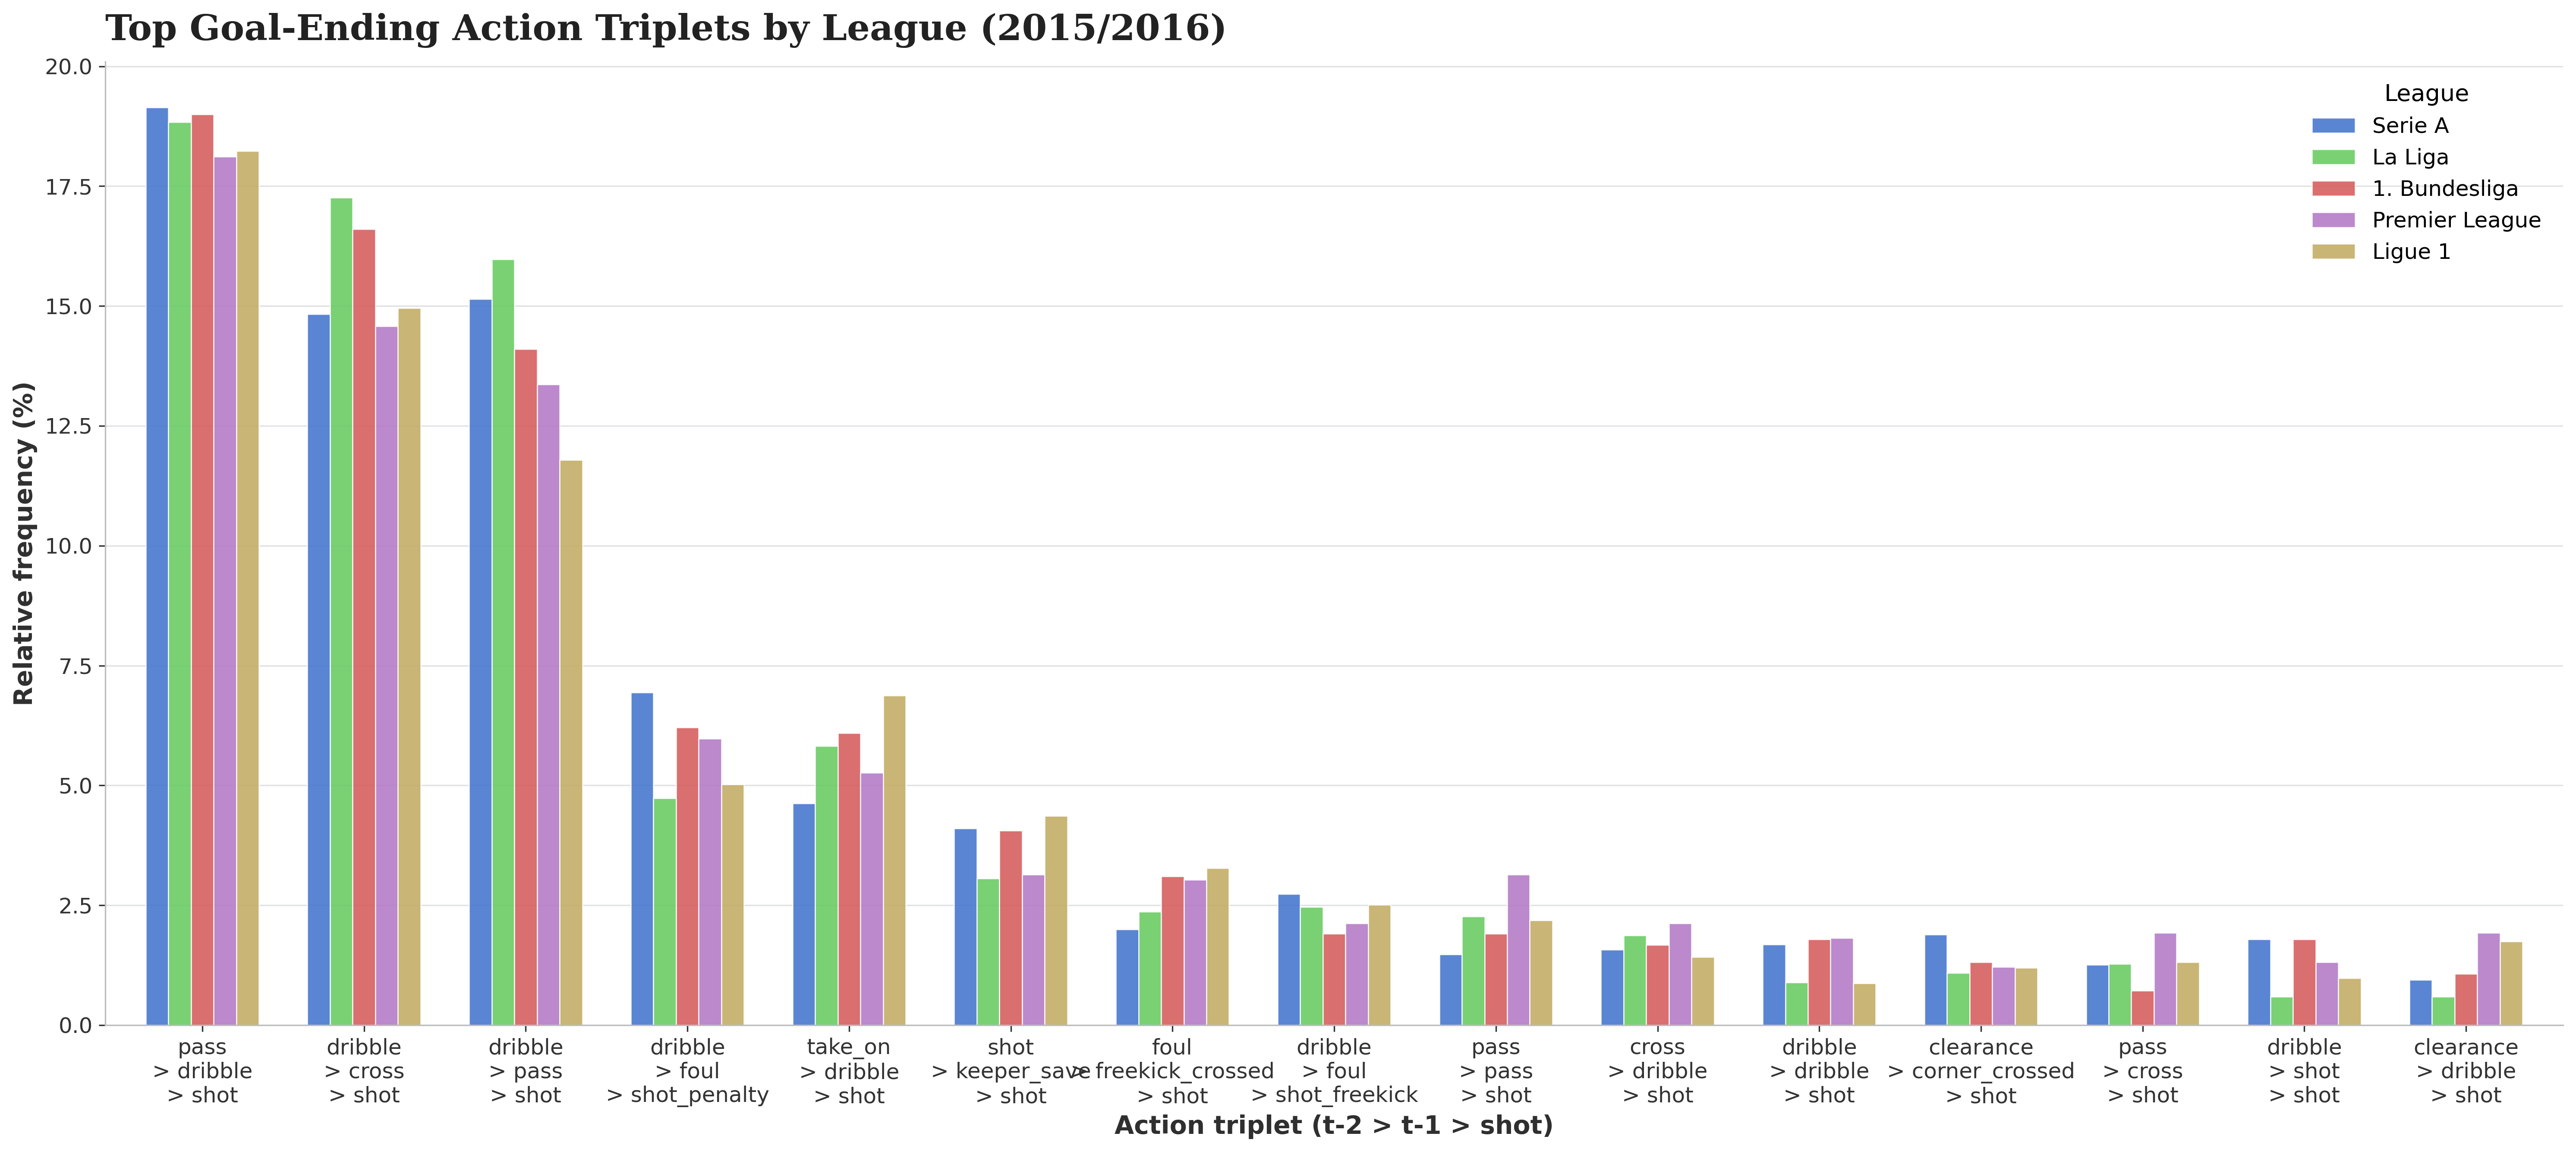

In [ ]:
n_triplets = len(plot_table)
n_leagues = len(plot_table.columns)
x = np.arange(n_triplets)
bar_width = 0.14
palette = ["#4878CF", "#6ACC65", "#D65F5F", "#B47CC7", "#C4AD66"]

fig, ax = plt.subplots(figsize=(15, 6), dpi=200)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for j, (league, color) in enumerate(zip(plot_table.columns, palette)):
    offset = (j - n_leagues / 2 + 0.5) * bar_width
    ax.bar(x + offset, plot_table[league], width=bar_width, label=league,
           color=color, alpha=0.88, edgecolor="white", linewidth=0.5)

short_labels = [t.replace(" -> ", " > ") for t in plot_table.index]
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=35, ha="right", fontsize=9)

ax.set_title(f"Top Goal-Ending Action Triplets by League ({selected_season})",
    fontsize=14, fontweight="semibold", color="#222222", loc="left", pad=10,
    fontfamily="DejaVu Serif")
ax.set_xlabel("Action triplet (t−2 > t−1 > shot)", fontsize=11, fontweight="semibold", color="#2f2f2f")
ax.set_ylabel("Relative frequency (%)", fontsize=11, fontweight="semibold", color="#2f2f2f")

ax.legend(title="League", title_fontsize=10, fontsize=9, frameon=False, loc="upper right", ncol=1)

ax.grid(axis="y", linestyle="-", linewidth=0.5, alpha=0.25, color="#9aa0a6")
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=10, colors="#333333")
ax.tick_params(axis="x", colors="#333333")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#bdbdbd")
ax.spines["bottom"].set_color("#bdbdbd")
ax.set_xlim(-0.5, n_triplets - 0.5)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


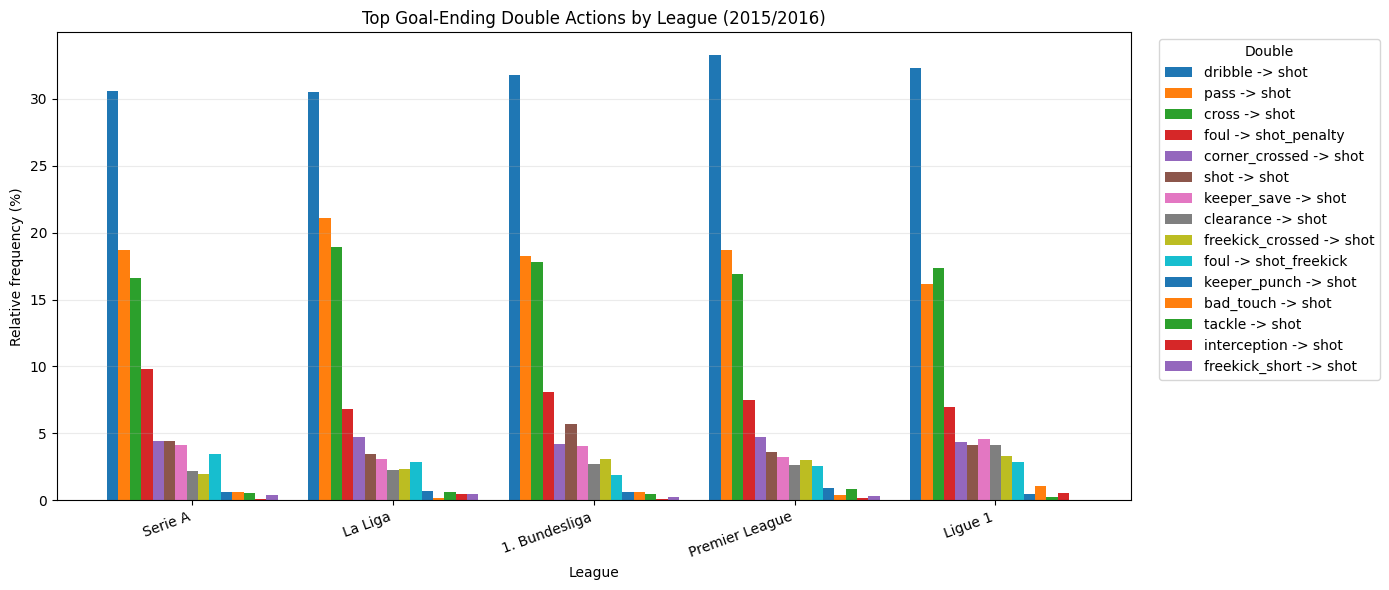

In [22]:
# Goal-ending DOUBLE actions (t-1 -> t) across top-5 leagues for one season
selected_season = "2015/2016"

top5_leagues = [
    "Serie A",
    "La Liga",
    "1. Bundesliga",
    "Premier League",
    "Ligue 1",
]

double_data = full_data.loc[
    full_data["season_name"].astype(str).eq(selected_season)
    & full_data["competition_name"].isin(top5_leagues)
].copy()


if "type_name" not in double_data.columns:
    actiontype_map = dict(enumerate(spadlcfg.actiontypes))
    double_data["type_name"] = double_data["type_id"].map(actiontype_map).fillna("unknown")

order_cols = [c for c in ["game_id", "period_id", "time_seconds", "action_id"] if c in double_data.columns]
double_data = double_data.sort_values(order_cols).copy()
double_data = mark_true_goal_actions(double_data)

double_data["type_t-1"] = double_data.groupby("game_id")["type_name"].shift(1)

goal_doubles = double_data.loc[
    double_data["is_true_goal_action"]
    & double_data["type_t-1"].notna()
].copy()


goal_doubles["double"] = goal_doubles["type_t-1"] + " -> " + goal_doubles["type_name"]

double_counts = (
    goal_doubles.groupby(["competition_name", "double"]).size().rename("count").reset_index())

double_counts["share_%"] = (
    double_counts.groupby("competition_name")["count"]
    .transform(lambda x: 100 * x / x.sum())
    .round(3)
)

double_cmp = (
    double_counts.pivot_table(
        index="double",
        columns="competition_name",
        values="share_%",
        fill_value=0,
    )
    .reindex(columns=top5_leagues, fill_value=0)
)
double_cmp = double_cmp.loc[double_cmp.mean(axis=1).sort_values(ascending=False).index]

# print(f"Goal-ending DOUBLE share (%) by league for season {selected_season}")
# display(double_cmp.round(3))

top_n_doubles = 15
plot_double = double_cmp.head(top_n_doubles)

fig, ax = plt.subplots(figsize=(14, 6))
plot_double.T.plot(kind="bar", ax=ax, width=0.85)
ax.set_title(f"Top Goal-Ending Double Actions by League ({selected_season})")
ax.set_xlabel("League")
ax.set_ylabel("Relative frequency (%)")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Double", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

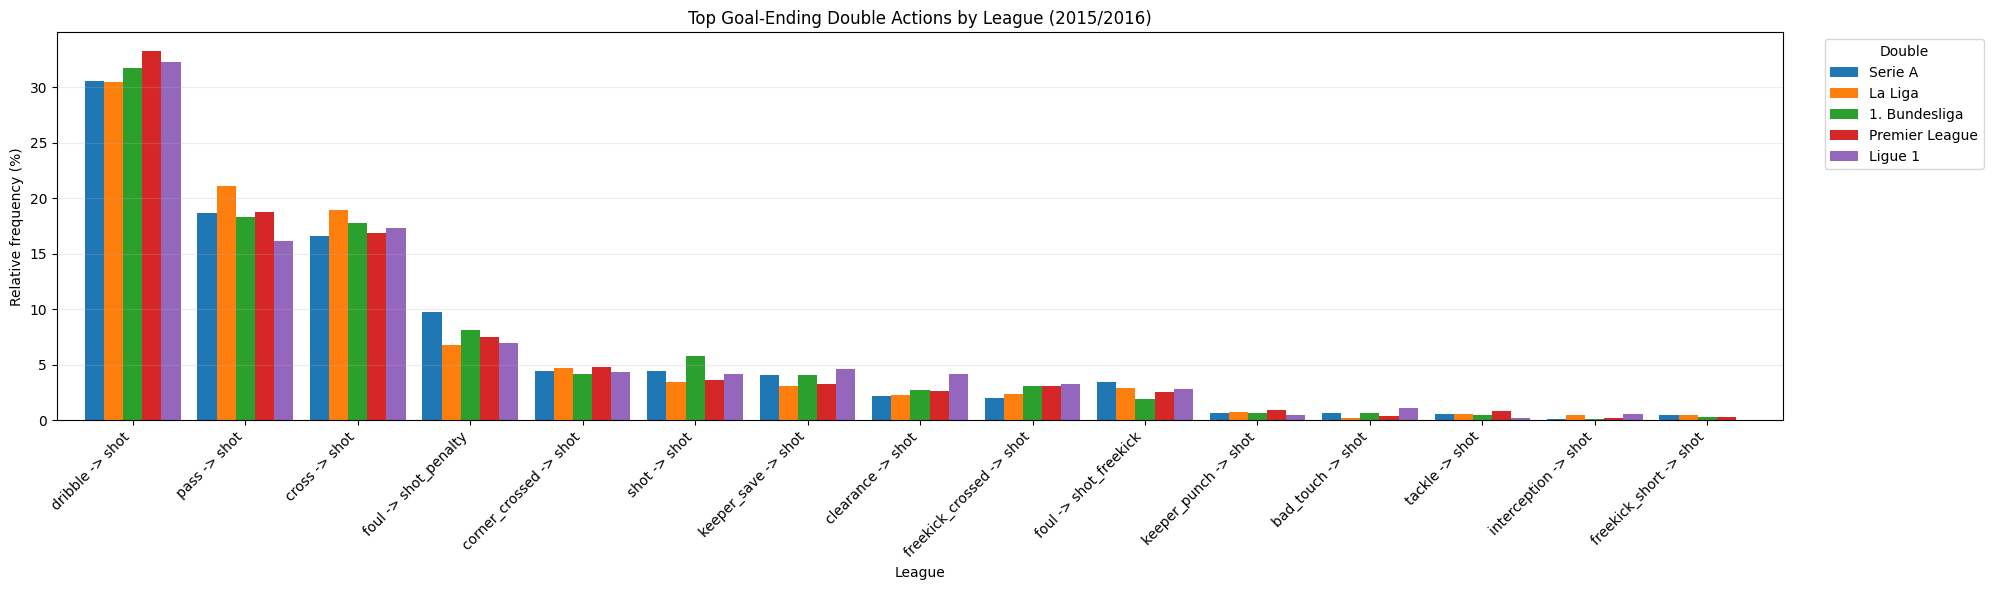

In [23]:
fig, ax = plt.subplots(figsize=(20, 6))
plot_double.plot(kind="bar", ax=ax, width=0.85)
ax.set_title(f"Top Goal-Ending Double Actions by League ({selected_season})")
ax.set_xlabel("League")
ax.set_ylabel("Relative frequency (%)")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Double", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Covariate Shift